## TendFollowing
* choose several US stocks, 
* trend justification
* backtesting

In [1]:
import threading
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from ibapi.client import EClient
from ibapi.wrapper import EWrapper
from ibapi.contract import Contract

class IBDataFetcher(EWrapper, EClient):
    def __init__(self):
        EClient.__init__(self, self)
        self.data  = []
        self.ready = threading.Event()  # TWS 握手完成
        self.done  = threading.Event()  # 数据接收完成

    def nextValidId(self, orderId):
        self.ready.set()  # 收到这个回调说明连接已就绪

    def historicalData(self, reqId, bar):
        self.data.append({
            'date':   bar.date,
            'open':   bar.open,
            'high':   bar.high,
            'low':    bar.low,
            'close':  bar.close,
            'volume': bar.volume,
        })

    def historicalDataEnd(self, reqId, start, end):
        self.done.set()

    def error(self, reqId, errorCode, errorString, advancedOrderRejectJson=''):
        if errorCode not in (2104, 2106, 2107, 2108, 2158):
            print(f'[ERROR] code={errorCode}: {errorString}')

def get_ibkr_data(symbol, duration='4 Y', bar_size='1 day', port=7497, client_id=1):
    """TWS 需在后台运行。port: 7497=模拟, 7496=真实"""
    print(f'extract {symbol}')
    app = IBDataFetcher()
    app.connect('127.0.0.1', port, clientId=client_id)

    contract = Contract()
    contract.symbol   = symbol
    contract.secType  = 'STK'
    contract.exchange = 'SMART'
    contract.currency = 'USD'

    threading.Thread(target=app.run, daemon=True).start()
    app.ready.wait(timeout=10)   # 等 nextValidId 回调，确认连接就绪

    app.reqHistoricalData(
        reqId=1, contract=contract, endDateTime='',
        durationStr=duration, barSizeSetting=bar_size,
        whatToShow='TRADES', useRTH=1, formatDate=1,
        keepUpToDate=False, chartOptions=[]
    )
    app.done.wait(timeout=60)
    app.disconnect()

    if not app.data:
        raise RuntimeError('没有收到数据，请确认 TWS 已开启且 API 已启用')

    df = pd.DataFrame(app.data)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    for col in ['open', 'high', 'low', 'close']:
        df[col] = df[col].astype(float)
    return df

In [ ]:
# # software company (never consider them)
# 'ORCL','NOW'
symbols = ['MU','WDC',  # Storage: Seagate, Micron, Western Digital 'STX',
    'NBIS','IREN','APLD','CORZ','EQIX','AMT', # data center 'GDS',
    'AMZN','GOOGL','META',   # Cloud for AI
    'NFLX', # MEDIA
    'NVDA','AVGO','TSLA','AMD','INTC',  # semiconductor(涉及软件业务的删掉)
    'AAPL','SMR',   # product
    'KO','PEP','WMT','COST','MCD', # FOOD/SUPERMARKET
    'GEV','VST','CEG','TLN','ETR','DUK','PNW','NEE','SRE','SO','D','WEC', # ENERGY
    'MSFT', 'IBM',  # X software
    'CRWV'  # X rent GPU for company
    ]
stock_yes = [
   'NBIS','IREN','APLD','CORZ','EQIX','AMT',
   'AMZN','GOOGL','META',
   'NVDA','AVGO','TSLA','AMD','INTC',
   'GEV','VST','CEG','TLN','PEG','ETR','DUK','PNW','NEE','SRE','SO','D','WEC',
]
# 电力-API, 逐一设置起止价格
'PEG','DUK','NEE','SRE','SO', # 美国公共服务集团、适合网格

In [ ]:
data_path = "/Users/litingmai/Desktop/AQuant/QuantifyA/IBKR/USstocks"
# startDate,endDate = '2022-01-01','2026-05-05'
for symbol in symbols:
    print(symbol)
    df_raw = get_ibkr_data(symbol, duration='4 Y')
    # df_raw = df_raw[(df_raw['date'] >= startDate) & (df_raw['date'] <= endDate)].reset_index(drop=True)
    print(f'{symbol}: {len(df_raw)} bars  {df_raw["date"].iloc[0].date()} -> {df_raw["date"].iloc[-1].date()}')

    df_raw.to_csv(f'{data_path}/data_{symbol}.csv', index=False)
    print(f'data_{symbol}.csv 已保存')
    # df_raw.tail()

In [2]:
import threading, time, logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter as _sg_filter
from ibapi.client import EClient
from ibapi.wrapper import EWrapper
from ibapi.contract import Contract
from ibapi.order import Order

logging.basicConfig(level=logging.INFO, format='%(asctime)s  %(levelname)s  %(message)s')
log = logging.getLogger('TrendFollower')

# ── Config ─────────────────────────────────────────────────────────────────────
SYMBOL     = 'NVDA'
BAR_SIZE   = '30 mins'   # '1 day' for daily
DURATION   = '30 D'      # IBKR history window (30 days of 30-min bars)
TREND_WIN  = 42          # bars in trend window  (42 × 30min ≈ 3.2 trading days)
TREND_LB   = 65          # bars for MA lookback  (65 × 30min ≈ 5 trading days)
TREND_THR  = 0.0005      # normalized slope threshold per bar (~0.05%/bar)
SHARES     = 10          # position size (shares per trade)
SL_PCT     = 0.03        # hard stop-loss (3%)
PORT       = 7497        # 7497=paper, 7496=live
CLIENT_ID  = 11
CHECK_SEC  = 1800        # poll interval (seconds) — 30 min


# ── Trend detection (same logic as MultiStrat_NVDA, windows configurable) ──────
def compute_price_trend(close_arr, win=TREND_WIN, lb=TREND_LB, thr=TREND_THR):
    """
    Multi-method normalized slope estimation.
    M1: linear fit on last `win` bars
    M2: linear fit on `win`-bar MA computed over `lb` bars
    M3: linear fit on 6-bar MA over `win` bars
    M4: exponentially weighted linear fit (recent bars heavier)
    Returns 'uptrend' | 'fluctuation' | 'downtrend' | 'unknown'
    """
    n = len(close_arr)
    if n < lb + 4:
        return 'unknown'

    LAMBDA = 0.8
    xwin   = np.arange(win, dtype=float)
    wexp   = np.array([LAMBDA ** (win - 1 - i) for i in range(win)])

    def _median_slope(end_idx):
        p_win = np.array(close_arr[end_idx - win + 1 : end_idx + 1], dtype=float)
        p_lb  = np.array(close_arr[end_idx - lb  + 1 : end_idx + 1], dtype=float)
        pmean = np.mean(p_win)
        if pmean == 0:
            return None
        sl = []

        s1, _ = np.polyfit(xwin, p_win, 1)
        sl.append(s1 / pmean)

        ma = np.convolve(p_lb, np.ones(win) / win, mode='valid')
        if len(ma) >= 3:
            s2, _ = np.polyfit(np.arange(len(ma), dtype=float), ma, 1)
            sl.append(s2 / np.mean(ma))

        ma6 = np.convolve(p_win, np.ones(6) / 6, mode='valid')
        if len(ma6) >= 3:
            s3, _ = np.polyfit(np.arange(len(ma6), dtype=float), ma6, 1)
            sl.append(s3 / np.mean(ma6))

        s4, _ = np.polyfit(xwin, p_win, 1, w=wexp)
        sl.append(s4 / pmean)

        return float(np.median(sl))

    med = _median_slope(n - 1)
    if med is None:
        return 'unknown'
    if med > thr:
        return 'uptrend'
    elif med < -thr:
        return 'downtrend'
    else:
        return 'fluctuation'


print(f'Config loaded — {SYMBOL}  {BAR_SIZE}  win={TREND_WIN}  lb={TREND_LB}  thr={TREND_THR}  port={PORT}')


Config loaded — NVDA  30 mins  win=42  lb=65  thr=0.0005  port=7497


In [ ]:
class IBTrendFollower(EWrapper, EClient):
    """
    IBKR paper-trading client for the trend-following strategy.
    - Polls every CHECK_SEC seconds (background thread)
    - Buys when trend flips to 'uptrend'
    - Sells when trend leaves 'uptrend', or stop-loss is hit
    """

    def __init__(self):
        EClient.__init__(self, self)
        # state
        self.pos    = 0
        self.avg_cost    = 0.0
        self.entry_price = None
        self.prev_trend  = 'unknown'
        self.next_oid    = 1
        self.trade_log   = []
        self._bars       = []
        # threading
        self._connected  = threading.Event()
        self._hist_done  = threading.Event()
        self._oid_ready  = threading.Event()
        self._stop       = threading.Event()

    # ── EWrapper callbacks ────────────────────────────────────────────────────
    def nextValidId(self, orderId):
        self.next_oid = orderId
        self._connected.set()
        self._oid_ready.set()

    def error(self, reqId, errorCode, errorString, advancedOrderRejectJson=''):
        if errorCode not in (2104, 2106, 2107, 2108, 2158):
            log.warning(f'[IBKR err {errorCode}] {errorString}')

    def historicalData(self, reqId, bar):
        self._bars.append({'date': bar.date, 'open': bar.open,
                           'high': bar.high,  'low': bar.low,
                           'close': bar.close, 'volume': bar.volume})

    def historicalDataEnd(self, reqId, start, end):
        self._hist_done.set()

    def position(self, account, contract, pos, avgCost):
        if contract.symbol == SYMBOL:
            self.pos = int(pos)
            self.avg_cost = float(avgCost)
            log.info(f'Position: {SYMBOL} {pos} shares @ avg {avgCost:.2f}')

    def positionEnd(self):
        pass

    def orderStatus(self, orderId, status, filled, remaining,
                    avgFillPrice, permId, parentId, lastFillPrice,
                    clientId, whyHeld, mktCapPrice):
        if filled > 0:
            log.info(f'Order {orderId} {status}: filled={filled} @ {avgFillPrice:.2f}')

    # ── Helpers ───────────────────────────────────────────────────────────────
    def _contract(self):
        c = Contract()
        c.symbol = SYMBOL; c.secType = 'STK'
        c.exchange = 'SMART'; c.currency = 'USD'
        return c

    def _next_oid(self):
        self._oid_ready.clear()
        self.reqIds(-1)
        self._oid_ready.wait(timeout=5)
        oid = self.next_oid
        self.next_oid += 1
        return oid

    def fetch_bars(self):
        """Fetch historical bars; returns a clean DataFrame."""
        self._bars = []
        self._hist_done.clear()
        self.reqHistoricalData(
            reqId=1, contract=self._contract(), endDateTime='',
            durationStr=DURATION, barSizeSetting=BAR_SIZE,
            whatToShow='TRADES', useRTH=1, formatDate=1,
            keepUpToDate=False, chartOptions=[]
        )
        if not self._hist_done.wait(timeout=60):
            log.error('fetch_bars timeout')
        df = pd.DataFrame(self._bars)
        if df.empty:
            return df
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        for col in ('open', 'high', 'low', 'close'):
            df[col] = df[col].astype(float)
        return df

    def _place_order(self, action, qty):
        o = Order()
        o.action = action; o.orderType = 'MKT'
        o.totalQuantity = qty; o.tif = 'DAY'
        oid = self._next_oid()
        self.placeOrder(oid, self._contract(), o)
        return oid

    def buy(self, price_ref):
        oid = self._place_order('BUY', SHARES)
        self.entry_price = price_ref
        log.info(f'BUY  oid={oid}  {SHARES} {SYMBOL} @ ~{price_ref:.2f}')
        self.trade_log.append({'time': pd.Timestamp.now(), 'action': 'BUY',
                               'price': price_ref, 'shares': SHARES})

    def sell(self, price_ref, reason):
        if self.pos <= 0:
            return
        qty = self.pos
        oid = self._place_order('SELL', qty)
        pnl = (price_ref - self.entry_price) * qty if self.entry_price else None
        log.info(f'SELL oid={oid}  {qty} {SYMBOL} @ ~{price_ref:.2f}  reason={reason}  pnl≈{pnl:.1f}')
        self.trade_log.append({'time': pd.Timestamp.now(), 'action': 'SELL',
                               'price': price_ref, 'reason': reason,
                               'shares': qty, 'pnl': pnl})
        self.entry_price = None

    # ── Strategy logic ────────────────────────────────────────────────────────
    def check_and_trade(self):
        df = self.fetch_bars()
        if df.empty or len(df) < TREND_LB + 4:
            log.warning(f'Insufficient bars: {len(df)}')
            return None, df

        cur_trend  = compute_price_trend(df['close'].values)
        last_close = float(df['close'].iloc[-1])
        last_time  = df['date'].iloc[-1]

        log.info(f'[{last_time}]  close={last_close:.2f}  '
                 f'trend={cur_trend}  prev={self.prev_trend}  pos={self.pos}')

        if self.prev_trend != 'uptrend' and cur_trend == 'uptrend' and self.pos == 0:
            self.buy(last_close)

        elif self.prev_trend == 'uptrend' and cur_trend != 'uptrend' and self.pos > 0:
            self.sell(last_close, reason=f'trend->{cur_trend}')

        elif self.pos > 0 and self.entry_price:
            ret = (last_close - self.entry_price) / self.entry_price
            if ret <= -SL_PCT:
                self.sell(last_close, reason=f'SL {ret:.1%}')

        self.prev_trend = cur_trend
        return cur_trend, df

    # ── Connect / run ─────────────────────────────────────────────────────────
    def start(self):
        self.connect('127.0.0.1', PORT, clientId=CLIENT_ID)
        threading.Thread(target=self.run, daemon=True).start()
        if not self._connected.wait(timeout=10):
            raise RuntimeError('Connection timeout — is TWS/Gateway running on port {}?'.format(PORT))
        self.reqPositions()
        time.sleep(1)
        log.info(f'Connected  port={PORT}  clientId={CLIENT_ID}')

    def start_live_loop(self):
        """Run check_and_trade every CHECK_SEC in a background thread."""
        self._stop.clear()
        def _loop():
            while not self._stop.is_set():
                try:
                    self.check_and_trade()
                except Exception as e:
                    log.error(f'Loop error: {e}')
                self._stop.wait(CHECK_SEC)
        t = threading.Thread(target=_loop, daemon=True, name='TrendLoop')
        t.start()
        log.info(f'Live loop started (interval={CHECK_SEC}s). Call trader.stop() to halt.')

    def stop(self):
        self._stop.set()
        self.disconnect()
        log.info('Stopped.')


print('IBTrendFollower class ready.')

In [ ]:
# ── Connect + start live loop ─────────────────────────────────────────────────
# Make sure TWS / IBKR Gateway is running and API access is enabled.
trader = IBTrendFollower()
trader.start()              # connect, sync existing position

trader.start_live_loop()    # background thread: check_and_trade every CHECK_SEC

# To do a one-off manual check right now:
# trend, df = trader.check_and_trade()

# To stop:
# trader.stop()

In [ ]:
# ── Monitor: chart + trade log ────────────────────────────────────────────────
# Re-run this cell any time to refresh the view.
df = trader.fetch_bars()           # 只拿数据，不交易
# _, df = trader.check_and_trade()   # fetch latest bars (no trade action, just data)

if df is not None and len(df) >= TREND_LB + 4:
    # rolling trend labels
    close_vals = df['close'].values
    trend_list = ['unknown'] * len(df)
    for i in range(TREND_LB + 3, len(df)):
        trend_list[i] = compute_price_trend(close_vals[:i + 1])
    df['trend']    = trend_list
    df['ma_short'] = df['close'].rolling(6).mean()
    df['ma_long']  = df['close'].rolling(TREND_WIN).mean()

    TREND_CLR = {'uptrend': '#d5f5e3', 'fluctuation': '#d6eaf8',
                 'downtrend': '#fadbd8', 'unknown': 'white'}
    xs = np.arange(len(df))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [4, 1]})

    # trend background
    seg_start, prev_t = 0, df['trend'].iloc[0]
    for i, t in enumerate(df['trend']):
        if t != prev_t:
            ax1.axvspan(seg_start - .5, i - .5, color=TREND_CLR.get(prev_t, 'white'), alpha=.4, lw=0)
            seg_start, prev_t = i, t
    ax1.axvspan(seg_start - .5, len(df) - .5, color=TREND_CLR.get(prev_t, 'white'), alpha=.4, lw=0)

    # candlesticks
    price_range = df['high'].max() - df['low'].min()
    offset = price_range * 0.02
    for i, row in df.iterrows():
        up = row['close'] >= row['open']
        c  = '#26a69a' if up else '#ef5350'
        ax1.plot([i, i], [row['low'], row['high']], color=c, lw=0.6, zorder=2)
        ax1.add_patch(plt.Rectangle(
            (i - 0.35, min(row['open'], row['close'])),
            0.70, max(abs(row['close'] - row['open']), 0.01), color=c, zorder=3))

    ax1.plot(xs, df['ma_short'], color='#e67e22', lw=1.2, label=f'MA6')
    ax1.plot(xs, df['ma_long'],  color='#8e44ad', lw=1.2, label=f'MA{TREND_WIN}')

    # trade markers
    date_to_x = {d: i for i, d in enumerate(df['date'])}
    for entry in trader.trade_log:
        xi = (df['date'] - entry['time']).abs().idxmin()
        if entry['action'] == 'BUY':
            ax1.plot(xi, df.loc[xi, 'low'] - offset, 'v', color='#2980b9', ms=10, zorder=6)
        else:
            c = '#27ae60' if (entry.get('pnl') or 0) >= 0 else '#e74c3c'
            ax1.plot(xi, df.loc[xi, 'high'] + offset, '^', color=c, ms=10, zorder=6)

    ax1.set_ylabel('Price ($)')
    ax1.set_title(f'{SYMBOL}  30-min Trend Follower  |  '
                  f'pos={trader.position}  entry={trader.entry_price}  trend={trader.prev_trend}',
                  fontsize=11)
    ax1.grid(alpha=0.15)
    ax1.set_xlim(-1, len(df))
    ax1.legend(handles=[
        Line2D([0],[0], color='#e67e22', lw=1.5, label='MA6'),
        Line2D([0],[0], color='#8e44ad', lw=1.5, label=f'MA{TREND_WIN}'),
        Line2D([0],[0], marker='v', color='#2980b9', ls='none', ms=8, label='BUY'),
        Line2D([0],[0], marker='^', color='#27ae60', ls='none', ms=8, label='SELL win'),
        Line2D([0],[0], marker='^', color='#e74c3c', ls='none', ms=8, label='SELL loss'),
        Patch(facecolor='#d5f5e3', alpha=.7, label='uptrend'),
        Patch(facecolor='#d6eaf8', alpha=.7, label='fluctuation'),
        Patch(facecolor='#fadbd8', alpha=.7, label='downtrend'),
    ], fontsize=8, loc='upper left', ncol=4)

    # volume
    vol_c = ['#26a69a' if df['close'].iloc[i] >= df['open'].iloc[i] else '#ef5350'
             for i in range(len(df))]
    ax2.bar(xs, df['volume'], color=vol_c, alpha=0.6, width=0.8)
    ax2.set_ylabel('Volume'); ax2.grid(alpha=0.15)

    step = max(1, len(df) // 20)
    ax2.set_xticks(xs[::step])
    ax2.set_xticklabels([str(df['date'].iloc[i]) for i in xs[::step]],
                        rotation=35, ha='right', fontsize=7)
    plt.tight_layout()
    plt.show()

# trade log
if trader.trade_log:
    print('\n--- Trade Log ---')
    print(pd.DataFrame(trader.trade_log).to_string(index=False))
else:
    print('No trades yet.')


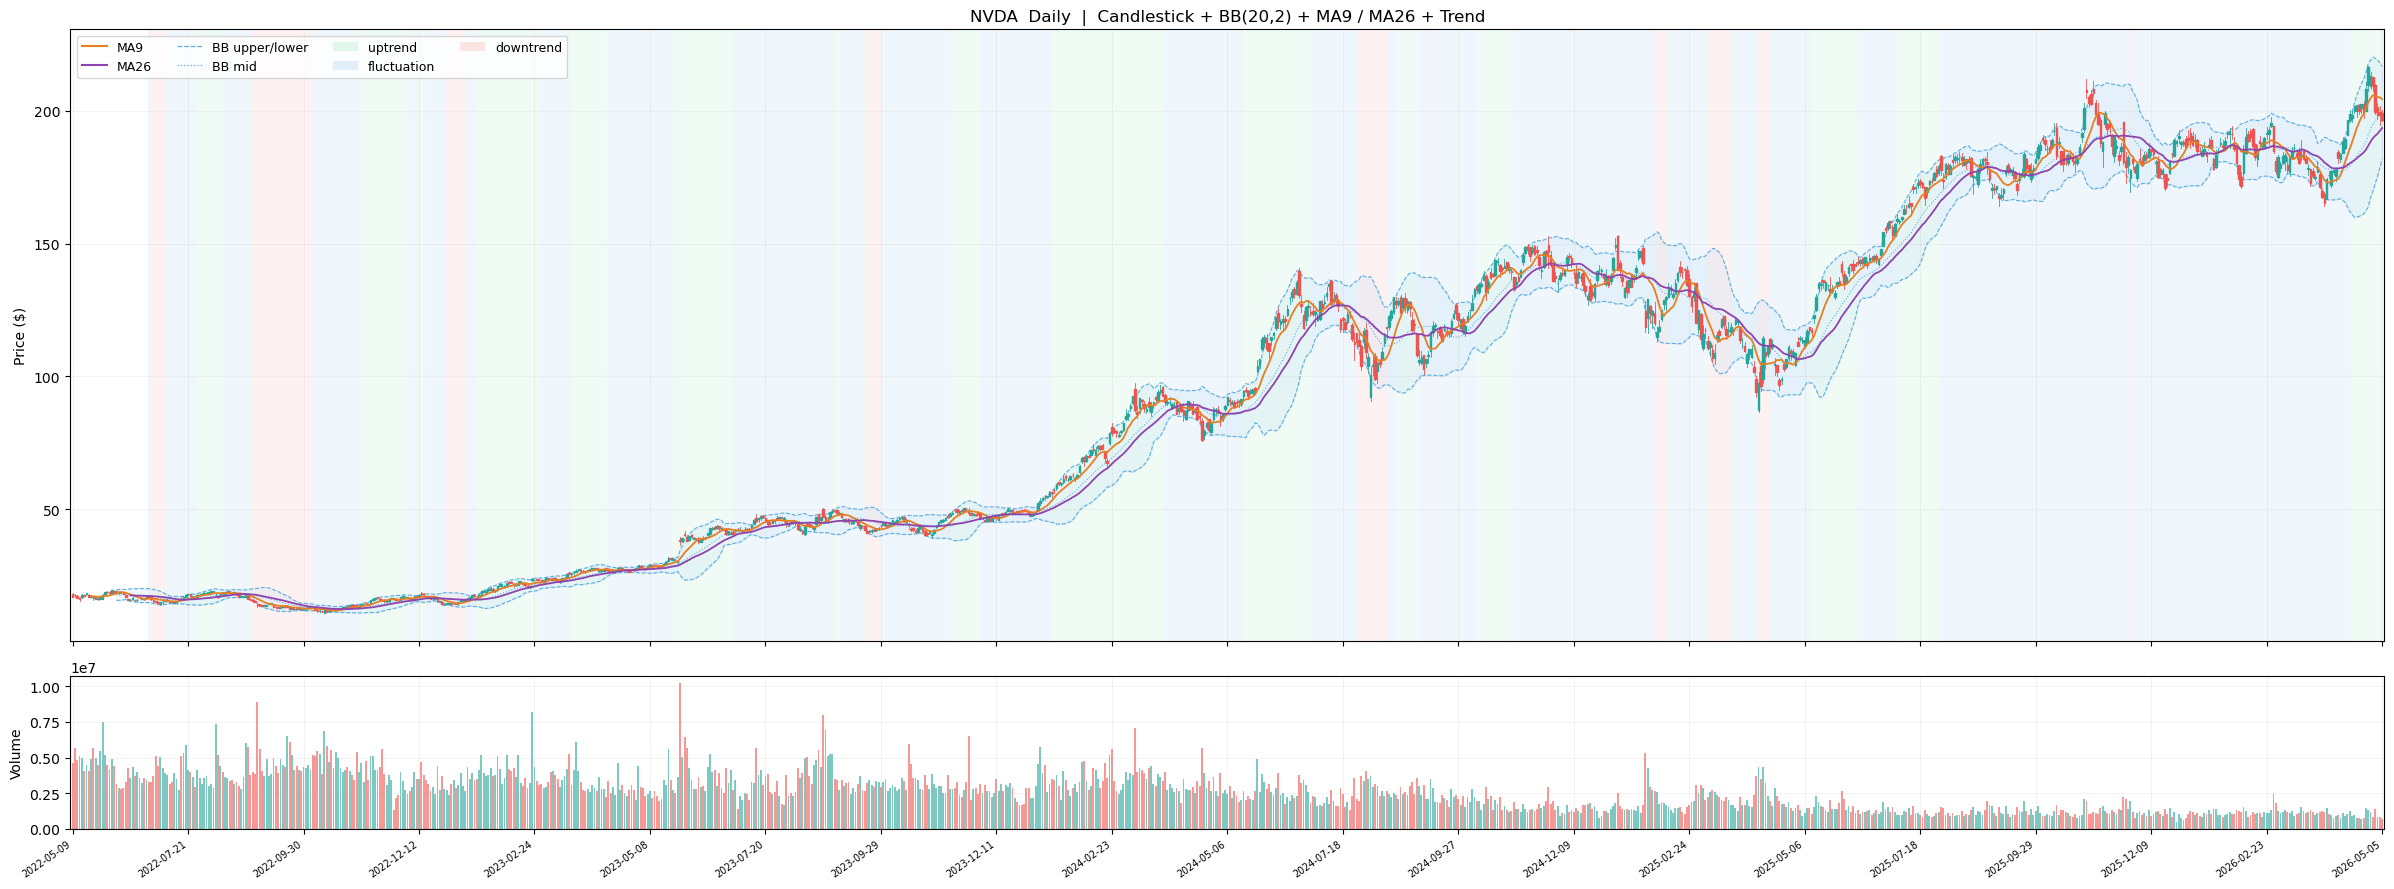

In [ ]:
import os
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

SAVE_DIR = '/Users/litingmai/Desktop/AQuant/QuantifyA/IBKR/USstocks'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Daily trend params (vs 30-min params used in live trader) ─────────────────
D_WIN = 21      # 21-day trend window
D_LB  = 30      # 30-day lookback for MA
D_THR = 0.0061  # normalized slope threshold per day


# ── Part 2: Chart — candlestick + BB(20,2) + MA9/26 + trend background ────────
def plot_trend_chart(symbol, save_dir=SAVE_DIR, win=D_WIN, lb=D_LB, thr=D_THR):
    fpath = os.path.join(save_dir, f'data_{symbol}.csv')
    df = pd.read_csv(fpath, parse_dates=['date'])
    df = df.sort_values('date').reset_index(drop=True)

    # ── Indicators ────────────────────────────────────────────────────────────
    df['ma9']  = df['close'].rolling(9).mean()
    df['ma26'] = df['close'].rolling(26).mean()

    bb_win = 20
    df['bb_mid']   = df['close'].rolling(bb_win).mean()
    df['bb_std']   = df['close'].rolling(bb_win).std()
    df['bb_upper'] = df['bb_mid'] + 2 * df['bb_std']
    df['bb_lower'] = df['bb_mid'] - 2 * df['bb_std']

    # rolling trend (uses compute_price_trend defined in cell 4)
    close_vals = df['close'].values
    trend_list = ['unknown'] * len(df)
    for i in range(lb + 3, len(df)):
        trend_list[i] = compute_price_trend(close_vals[:i + 1], win=win, lb=lb, thr=thr)
    df['trend'] = trend_list

    # ── Layout ────────────────────────────────────────────────────────────────
    TREND_CLR = {
        'uptrend':     '#d5f5e3',
        'fluctuation': '#d6eaf8',
        'downtrend':   '#fadbd8',
        'unknown':     'white',
    }
    xs          = np.arange(len(df))
    price_range = df['high'].max() - df['low'].min()
    min_body    = price_range * 0.001

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(24, 9), sharex=True,
        gridspec_kw={'height_ratios': [4, 1]}
    )

    # ── Trend background ──────────────────────────────────────────────────────
    seg_start, prev_t = 0, df['trend'].iloc[0]
    for i, t in enumerate(df['trend']):
        if t != prev_t:
            ax1.axvspan(seg_start - .5, i - .5,
                        color=TREND_CLR.get(prev_t, 'white'), alpha=.35, lw=0)
            seg_start, prev_t = i, t
    ax1.axvspan(seg_start - .5, len(df) - .5,
                color=TREND_CLR.get(prev_t, 'white'), alpha=.35, lw=0)

    # ── Bollinger Bands ───────────────────────────────────────────────────────
    ax1.fill_between(xs, df['bb_lower'], df['bb_upper'],
                     color='#aed6f1', alpha=0.18, zorder=1)
    ax1.plot(xs, df['bb_upper'], color='#5dade2', lw=0.8, ls='--', zorder=2)
    ax1.plot(xs, df['bb_mid'],   color='#5dade2', lw=0.8, ls=':',  zorder=2)
    ax1.plot(xs, df['bb_lower'], color='#5dade2', lw=0.8, ls='--', zorder=2)

    # ── MA9 / MA26 ────────────────────────────────────────────────────────────
    ax1.plot(xs, df['ma9'],  color='#e67e22', lw=1.3, zorder=4)
    ax1.plot(xs, df['ma26'], color='#8e44ad', lw=1.3, zorder=4)

    # ── Candlesticks ──────────────────────────────────────────────────────────
    for i, row in df.iterrows():
        up = row['close'] >= row['open']
        c  = '#26a69a' if up else '#ef5350'
        ax1.plot([i, i], [row['low'], row['high']], color=c, lw=0.6, zorder=3)
        ax1.add_patch(plt.Rectangle(
            (i - 0.35, min(row['open'], row['close'])),
            0.70, max(abs(row['close'] - row['open']), min_body),
            color=c, zorder=3
        ))

    ax1.set_ylabel('Price ($)')
    ax1.set_title(f'{symbol}  Daily  |  Candlestick + BB(20,2) + MA9 / MA26 + Trend', fontsize=12)
    ax1.grid(alpha=0.15)
    ax1.set_xlim(-1, len(df))
    ax1.legend(handles=[
        Line2D([0], [0], color='#e67e22', lw=1.5, label='MA9'),
        Line2D([0], [0], color='#8e44ad', lw=1.5, label='MA26'),
        Line2D([0], [0], color='#5dade2', lw=0.9, ls='--', label='BB upper/lower'),
        Line2D([0], [0], color='#5dade2', lw=0.9, ls=':',  label='BB mid'),
        Patch(facecolor='#d5f5e3', alpha=.7, label='uptrend'),
        Patch(facecolor='#d6eaf8', alpha=.7, label='fluctuation'),
        Patch(facecolor='#fadbd8', alpha=.7, label='downtrend'),
    ], fontsize=9, loc='upper left', ncol=4)

    # ── Volume ────────────────────────────────────────────────────────────────
    vol_c = ['#26a69a' if df['close'].iloc[i] >= df['open'].iloc[i] else '#ef5350'
             for i in range(len(df))]
    ax2.bar(xs, df['volume'], color=vol_c, alpha=0.6, width=0.8)
    ax2.set_ylabel('Volume')
    ax2.grid(alpha=0.15)

    step = max(1, len(df) // 20)
    ax2.set_xticks(xs[::step])
    ax2.set_xticklabels([str(df['date'].iloc[i].date()) for i in xs[::step]],rotation=35, ha='right', fontsize=7)
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"/Users/litingmai/Desktop/AQuant/QuantifyA/IBKR/figures/{symbol}.png")
    
for symbol in symbols:
    plot_trend_chart(symbol)